# Test ViFashionCLIP với ảnh trong `TestImages`

Notebook này dùng để kiểm tra nhanh model FashionCLIP tiếng Việt đã fine-tune:

- Ảnh: encode bằng **FashionCLIP image encoder gốc**.
- Text tiếng Việt: encode bằng **AITeamVN/Vietnamese_Embedding_v2 + ProjectionHead Stage 2**.
- So khớp bằng cosine similarity/dot product trong cùng không gian 512 chiều.

Mục tiêu: nhập query tiếng Việt như `áo khoác denim xanh`, model trả về top ảnh phù hợp nhất trong folder `TestImages`.

## 1. Import thư viện và khai báo đường dẫn

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, CLIPProcessor, CLIPVisionModelWithProjection

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ROOT = Path.cwd()
if ROOT.name.lower() == "vietnamese":
    VI_DIR = ROOT
else:
    VI_DIR = ROOT / "Chatbot_Fashion" / "Vietnamese"

WORKSPACE = VI_DIR.parents[1]
TEST_IMAGE_DIR = WORKSPACE / "Chatbot_Fashion" / "English" / "multimodal_rag" / "TestImages"
CHECKPOINT_PATH = VI_DIR / "vifashionclip_aiteamvn_embedding_v2_projection_336k" / "stage2_last_layers" / "best_stage2_model.pt"

TEACHER_MODEL_NAME = "patrickjohncyh/fashion-clip"
STUDENT_MODEL_NAME = "AITeamVN/Vietnamese_Embedding_v2"
STUDENT_MAX_LENGTH = 128
PROJECTION_HIDDEN_DIM = 1024
PROJECTION_NUM_LAYERS = 3
PROJECTION_DROPOUT = 0.05

print("Vietnamese dir:", VI_DIR)
print("Test image dir:", TEST_IMAGE_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())
print("Test image dir exists:", TEST_IMAGE_DIR.exists())

Device: cpu
Vietnamese dir: d:\KHÓA LUẬN\WORKSPACE\Chatbot_Fashion\Vietnamese
Test image dir: d:\KHÓA LUẬN\WORKSPACE\Chatbot_Fashion\English\multimodal_rag\TestImages
Checkpoint: d:\KHÓA LUẬN\WORKSPACE\Chatbot_Fashion\Vietnamese\vifashionclip_aiteamvn_embedding_v2_projection_336k\stage2_last_layers\best_stage2_model.pt
Checkpoint exists: True
Test image dir exists: True


## 2. Định nghĩa kiến trúc text encoder tiếng Việt

Kiến trúc này phải khớp với notebook train:

`Vietnamese_Embedding_v2 -> mean pooling -> ProjectionHead -> vector 512 chiều`

In [2]:
class ResidualMLPBlock(nn.Module):
    def __init__(self, dim, dropout=0.05):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.block(x)


class ProjectionHead(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=1024, num_layers=3, dropout=0.05):
        super().__init__()
        layers = [
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        ]
        for _ in range(max(0, num_layers - 2)):
            layers.append(ResidualMLPBlock(hidden_dim, dropout=dropout))
        layers.extend([
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, output_dim),
        ])
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    denom = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / denom


class Stage2StudentProjection(nn.Module):
    def __init__(self, encoder, projection_head):
        super().__init__()
        self.encoder = encoder
        self.projection_head = projection_head

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = mean_pool(outputs.last_hidden_state, attention_mask)
        projected = self.projection_head(pooled)
        return projected


print("[OK] Architecture defined")

[OK] Architecture defined


## 3. Load model

Cell này load 2 nhánh:

- `vi_text_model`: text encoder tiếng Việt đã fine-tune.
- `vision_model`: image encoder FashionCLIP gốc.

In [3]:
def load_vi_text_model(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location="cpu")
    student_name = checkpoint.get("student_model_name", STUDENT_MODEL_NAME)
    teacher_dim = int(checkpoint.get("teacher_dim", 512))

    tokenizer = AutoTokenizer.from_pretrained(student_name)
    encoder = AutoModel.from_pretrained(student_name)
    projection = ProjectionHead(
        input_dim=encoder.config.hidden_size,
        output_dim=teacher_dim,
        hidden_dim=PROJECTION_HIDDEN_DIM,
        num_layers=PROJECTION_NUM_LAYERS,
        dropout=PROJECTION_DROPOUT,
    )

    encoder.load_state_dict(checkpoint["encoder_state_dict"])
    projection.load_state_dict(checkpoint["projection_state_dict"])

    model = Stage2StudentProjection(encoder, projection).to(DEVICE).eval()
    return tokenizer, model, checkpoint


vi_tokenizer, vi_text_model, checkpoint = load_vi_text_model(CHECKPOINT_PATH)

vision_model = CLIPVisionModelWithProjection.from_pretrained(TEACHER_MODEL_NAME).to(DEVICE).eval()
vision_processor = CLIPProcessor.from_pretrained(TEACHER_MODEL_NAME)

for p in vi_text_model.parameters():
    p.requires_grad = False
for p in vision_model.parameters():
    p.requires_grad = False

print("[OK] Loaded Vietnamese text model")
print("[OK] Loaded FashionCLIP image encoder")
print("Checkpoint keys:", list(checkpoint.keys()))
print("Student dim:", checkpoint.get("student_dim"), "-> Teacher/FashionCLIP dim:", checkpoint.get("teacher_dim"))
print("Stage2 config:", checkpoint.get("stage2_config"))

config.json:   0%|          | 0.00/664 [00:00<?, ?B/s]

c:\Users\DELL\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\DELL\.cache\huggingface\hub\models--AITeamVN--Vietnamese_Embedding_v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: patrickjohncyh/fashion-clip
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.embeddings.position_ids                         | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.embeddings.position_embedding.weight              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn

[OK] Loaded Vietnamese text model
[OK] Loaded FashionCLIP image encoder
Checkpoint keys: ['encoder_state_dict', 'projection_state_dict', 'student_model_name', 'teacher_model_name', 'student_dim', 'teacher_dim', 'stage2_config']
Student dim: 1024 -> Teacher/FashionCLIP dim: 512
Stage2 config: {'unfreeze_last_n': 2, 'encoder_lr': 2e-06, 'projection_lr': 0.0001, 'batch_size': 128, 'epochs': 10, 'lambda_align': 48.0, 'beta_struct': 1.0, 'gamma_contrastive': 1.0, 'contrastive_temperature': 0.07}


## 4. Xem toàn bộ ảnh test

Số ảnh: 10
- test1.jpg
- test10.jpg
- test2.jpg
- test3.jpg
- test4.jpg
- test5.jpg
- test6.jpg
- test7.png
- test8.jpg
- test9.jpg


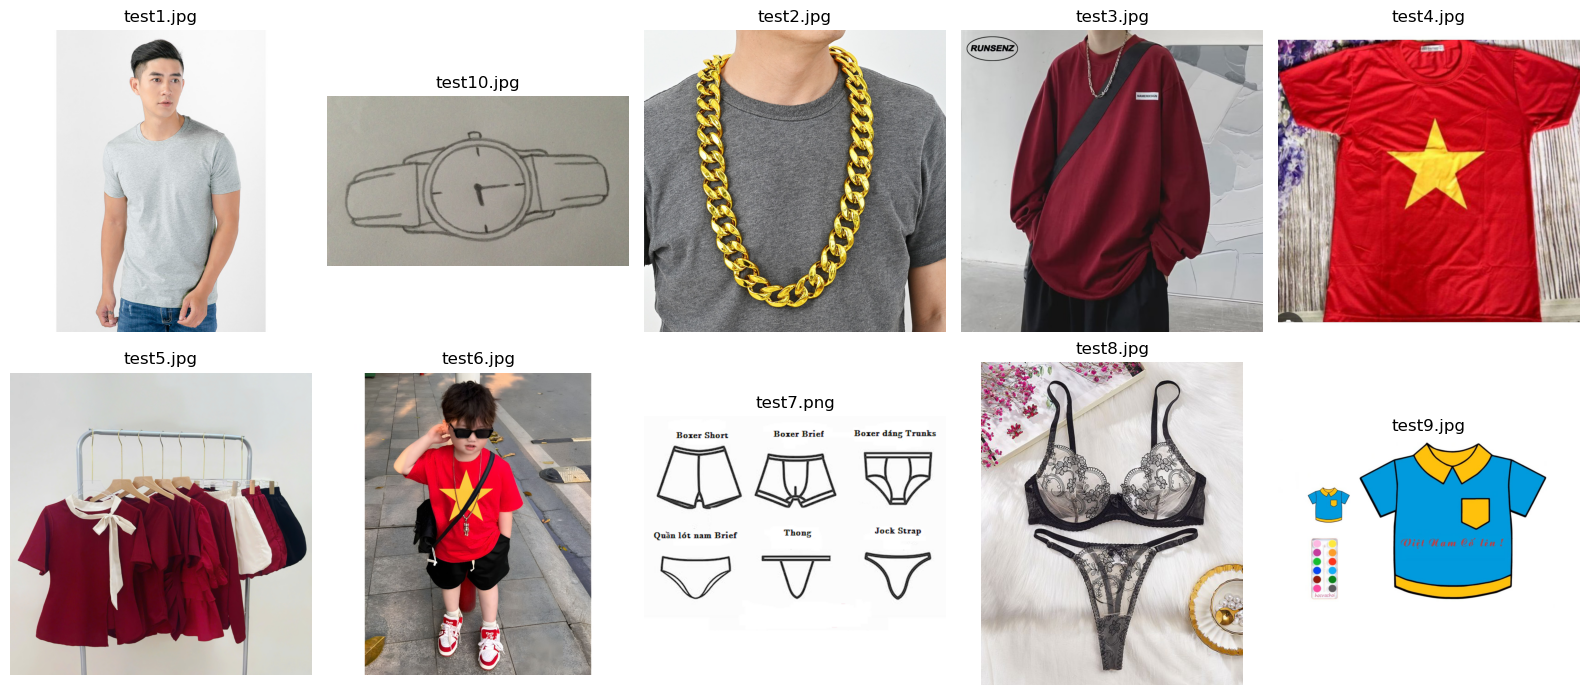

In [4]:
image_paths = sorted([
    p for p in TEST_IMAGE_DIR.iterdir()
    if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp"}
])

print("Số ảnh:", len(image_paths))
for p in image_paths:
    print("-", p.name)

cols = 5
rows = (len(image_paths) + cols - 1) // cols
plt.figure(figsize=(16, 3.5 * rows))
for i, path in enumerate(image_paths, start=1):
    img = Image.open(path).convert("RGB")
    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ax.set_title(path.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Encode ảnh và text

In [5]:
@torch.no_grad()
def encode_images(paths, batch_size=8):
    all_embeds = []
    for i in tqdm(range(0, len(paths), batch_size), desc="Encode images"):
        batch_paths = paths[i:i + batch_size]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = vision_processor(images=images, return_tensors="pt").to(DEVICE)
        embeds = vision_model(**inputs).image_embeds
        embeds = F.normalize(embeds, p=2, dim=-1)
        all_embeds.append(embeds.cpu())
    return torch.cat(all_embeds, dim=0)


@torch.no_grad()
def encode_vi_texts(texts, batch_size=16):
    all_embeds = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encode Vietnamese text"):
        batch = [str(x) for x in texts[i:i + batch_size]]
        inputs = vi_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=STUDENT_MAX_LENGTH,
            return_tensors="pt",
        ).to(DEVICE)
        embeds = vi_text_model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        embeds = F.normalize(embeds, p=2, dim=-1)
        all_embeds.append(embeds.cpu())
    return torch.cat(all_embeds, dim=0)


image_embeds = encode_images(image_paths)
print("Image embeds shape:", image_embeds.shape)

Encode images:   0%|          | 0/2 [00:00<?, ?it/s]

Image embeds shape: torch.Size([10, 512])


## 6. Hàm search ảnh bằng query tiếng Việt

In [6]:
def search_images_vi(query, top_k=5):
    query_embed = encode_vi_texts([query])
    scores = (query_embed @ image_embeds.T).squeeze(0)
    top_scores, top_indices = torch.topk(scores, k=min(top_k, len(image_paths)))

    print(f"Query: {query}")
    print("Top results:")
    for rank, (score, idx) in enumerate(zip(top_scores.tolist(), top_indices.tolist()), start=1):
        print(f"{rank}. {image_paths[idx].name} | score={score:.4f}")

    cols = len(top_indices)
    plt.figure(figsize=(4 * cols, 4))
    for plot_i, (score, idx) in enumerate(zip(top_scores.tolist(), top_indices.tolist()), start=1):
        img = Image.open(image_paths[idx]).convert("RGB")
        ax = plt.subplot(1, cols, plot_i)
        ax.imshow(img)
        ax.set_title(f"#{plot_i} {image_paths[idx].name}\nscore={score:.3f}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    return [(image_paths[idx].name, float(score)) for score, idx in zip(top_scores.tolist(), top_indices.tolist())]


print("[OK] search_images_vi(query, top_k=5) is ready")

[OK] search_images_vi(query, top_k=5) is ready


## 7. Test nhanh với nhiều query tiếng Việt

Bạn có thể sửa danh sách query bên dưới theo nội dung ảnh trong folder `TestImages`.

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

Query: áo khoác denim màu xanh
Top results:
1. test9.jpg | score=0.1336
2. test1.jpg | score=0.1212
3. test10.jpg | score=0.0976
4. test2.jpg | score=0.0934
5. test4.jpg | score=0.0909


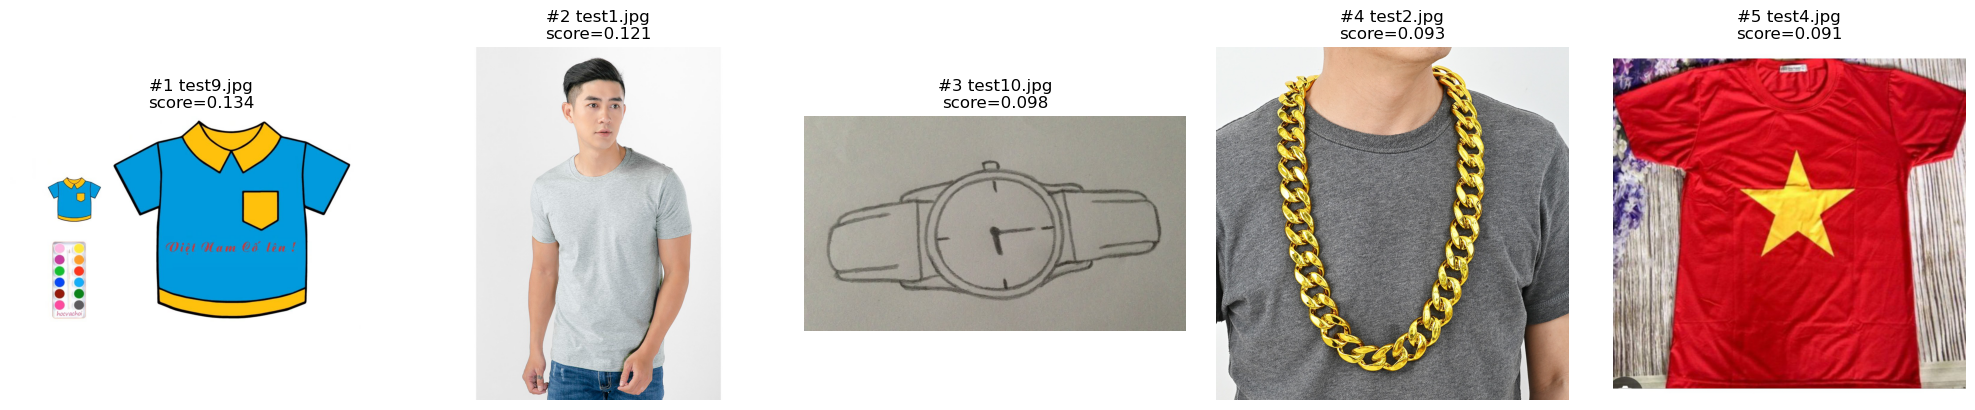

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

Query: váy liền màu đen
Top results:
1. test10.jpg | score=0.1877
2. test8.jpg | score=0.1564
3. test6.jpg | score=0.1354
4. test4.jpg | score=0.1350
5. test5.jpg | score=0.1269


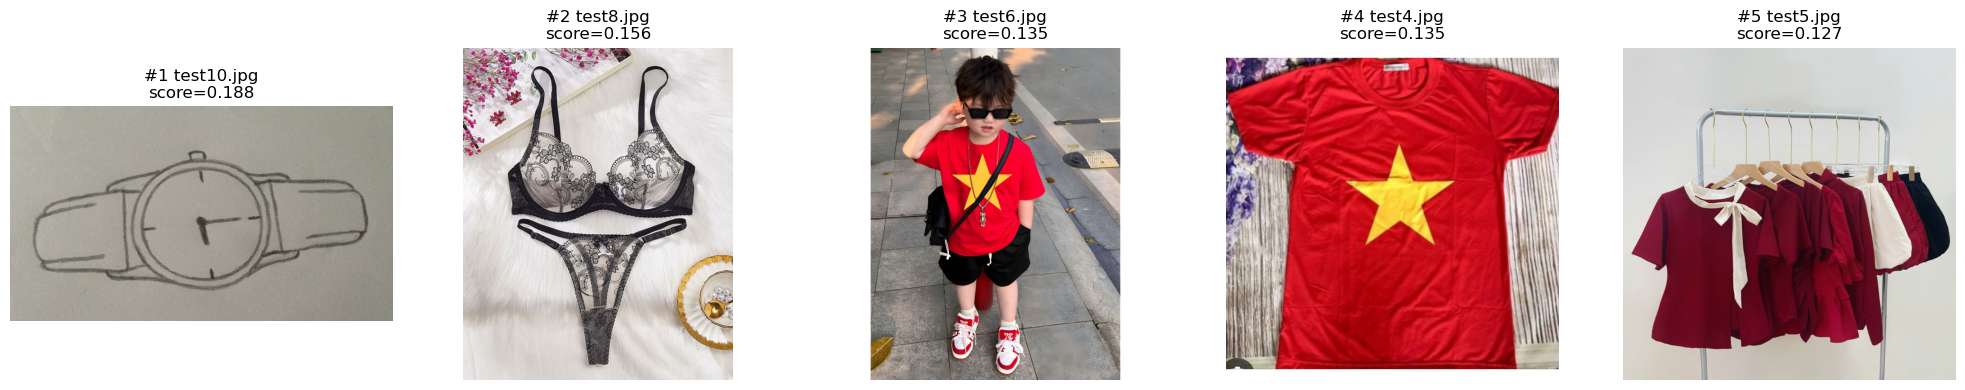

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

Query: quần jeans xanh dáng suông
Top results:
1. test1.jpg | score=0.2449
2. test9.jpg | score=0.1978
3. test7.png | score=0.1525
4. test2.jpg | score=0.1478
5. test6.jpg | score=0.1429


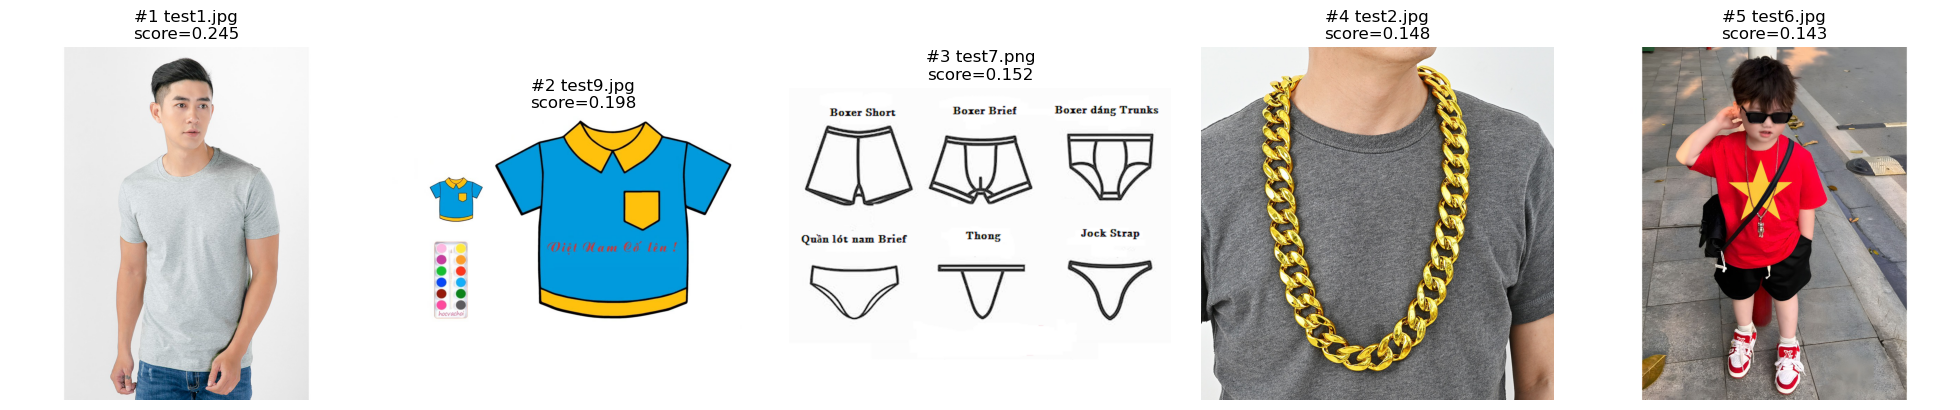

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

Query: áo sơ mi trắng tay dài
Top results:
1. test3.jpg | score=0.1905
2. test9.jpg | score=0.1898
3. test10.jpg | score=0.1855
4. test7.png | score=0.1822
5. test5.jpg | score=0.1819


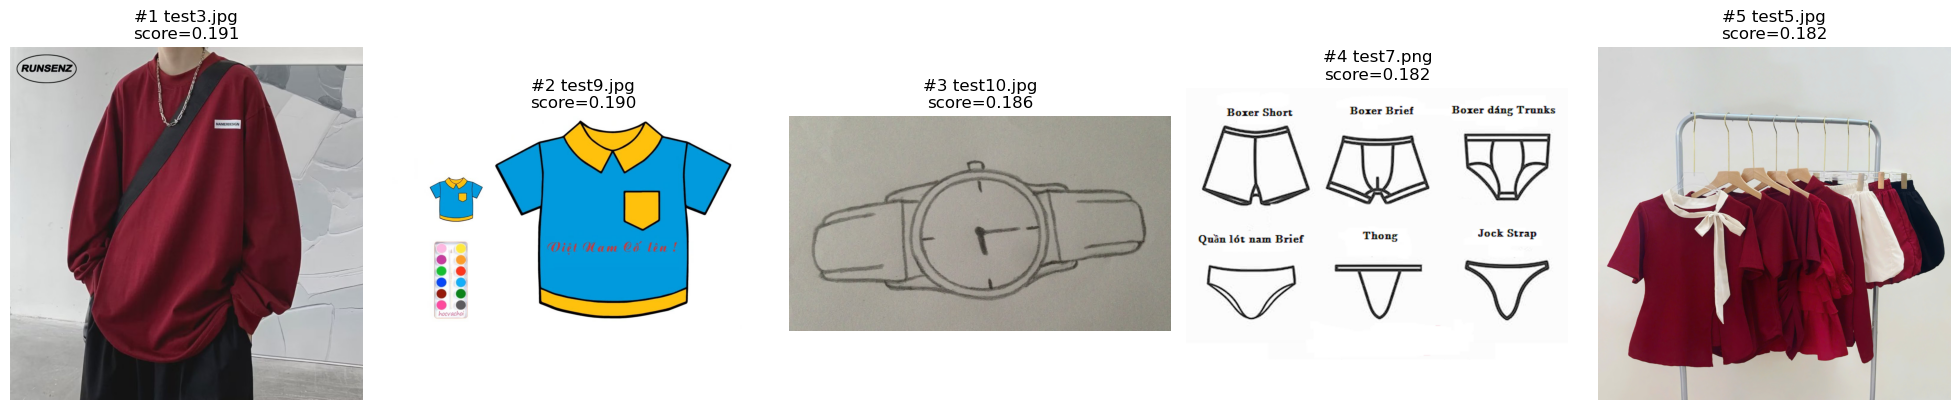

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

Query: giày thể thao màu trắng
Top results:
1. test6.jpg | score=0.1377
2. test10.jpg | score=0.1233
3. test9.jpg | score=0.1000
4. test1.jpg | score=0.0909
5. test4.jpg | score=0.0865


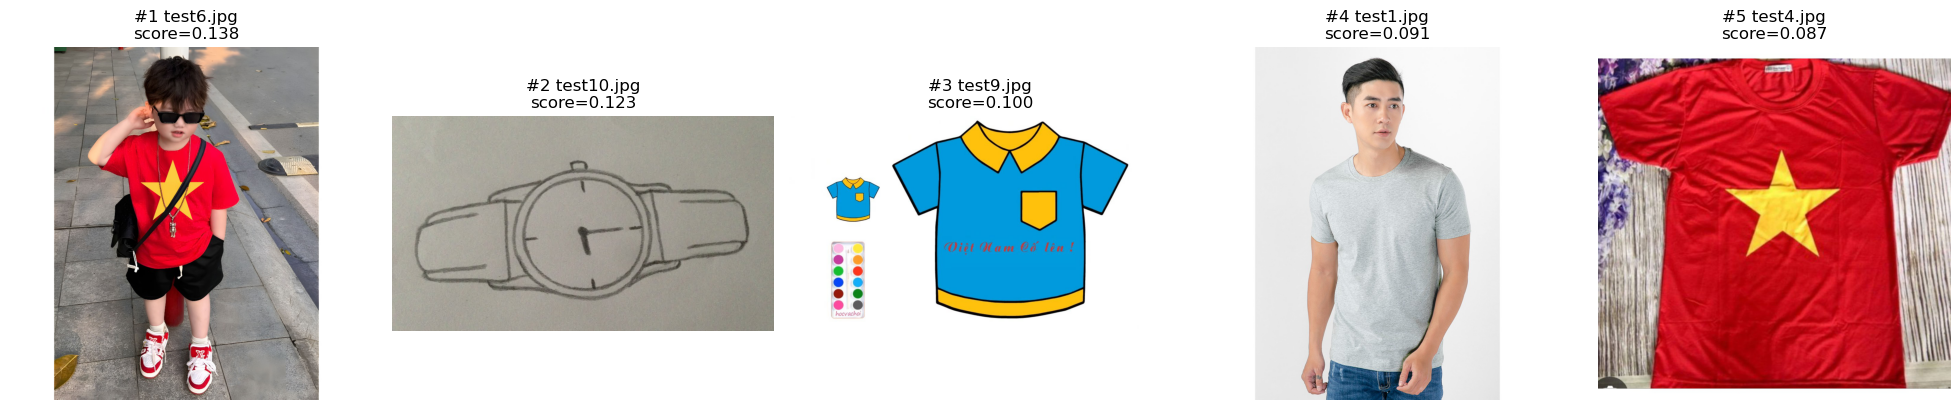

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

Query: túi xách màu đen
Top results:
1. test10.jpg | score=0.1517
2. test6.jpg | score=0.1376
3. test8.jpg | score=0.1175
4. test5.jpg | score=0.0993
5. test3.jpg | score=0.0954


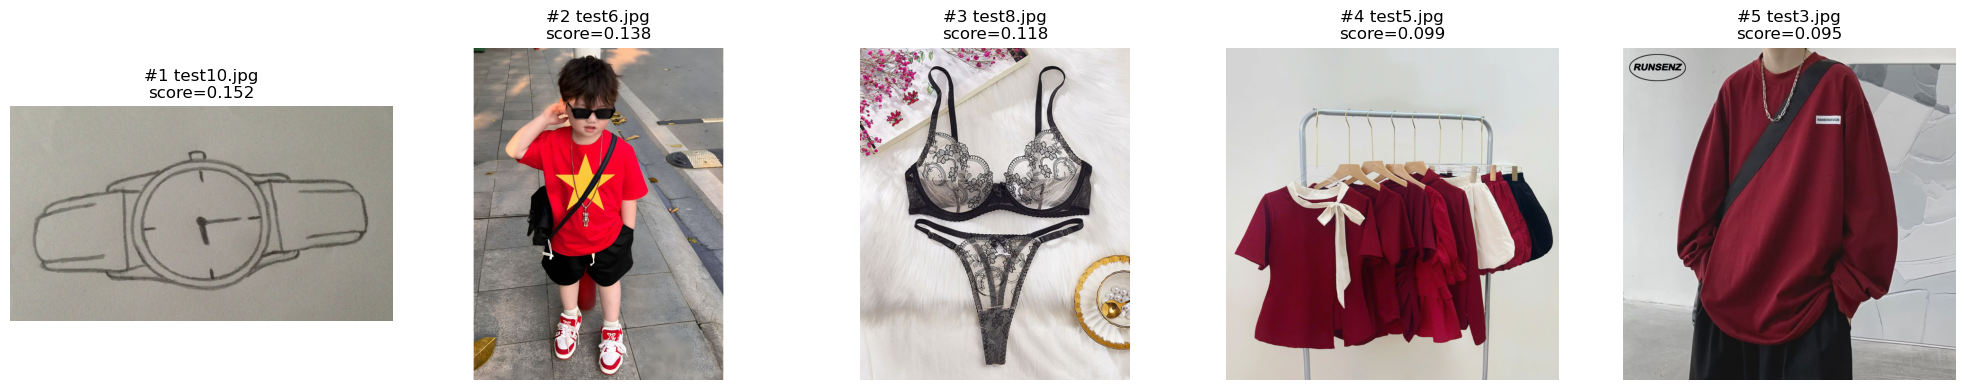

In [7]:
test_queries = [
    "áo khoác denim màu xanh",
    "váy liền màu đen",
    "quần jeans xanh dáng suông",
    "áo sơ mi trắng tay dài",
    "giày thể thao màu trắng",
    "túi xách màu đen",
]

for query in test_queries:
    search_images_vi(query, top_k=5)

## 8. Tự nhập query để test

Chạy cell này rồi đổi biến `my_query` thành câu bạn muốn test.

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

Query: đồ lót
Top results:
1. test7.png | score=0.3735
2. test8.jpg | score=0.2784
3. test5.jpg | score=0.2236
4. test9.jpg | score=0.1884
5. test4.jpg | score=0.1642


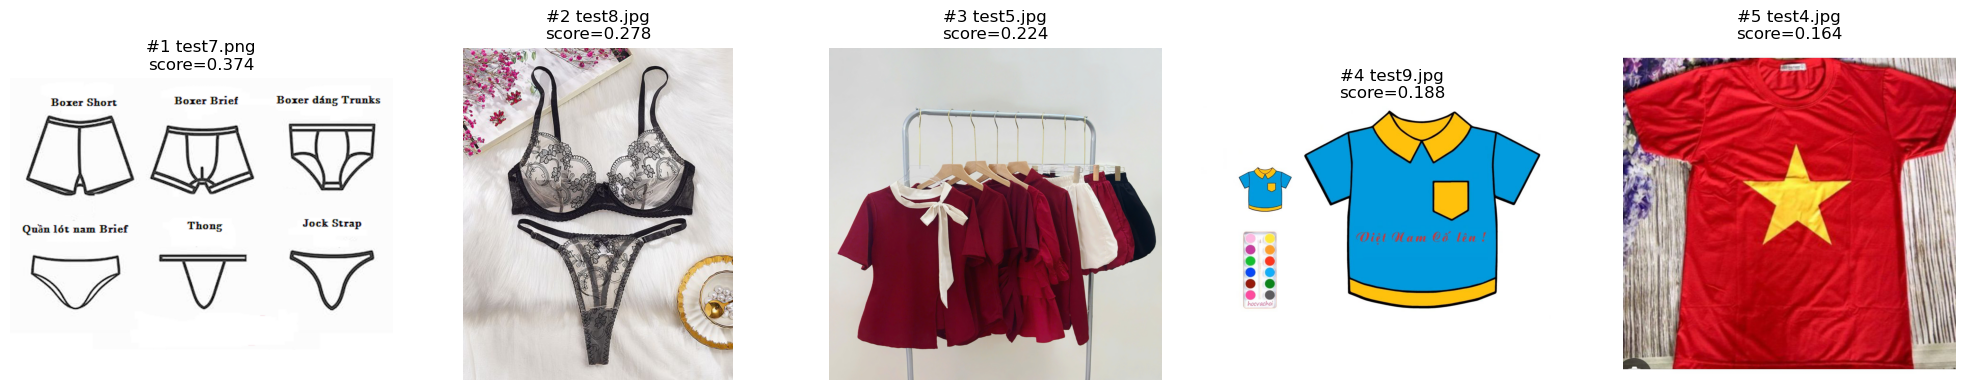

[('test7.png', 0.37350529432296753),
 ('test8.jpg', 0.2784193456172943),
 ('test5.jpg', 0.2235625982284546),
 ('test9.jpg', 0.1883547604084015),
 ('test4.jpg', 0.16420100629329681)]

In [15]:
my_query = "đồ lót"
search_images_vi(my_query, top_k=5)

## 9. Test text-to-image dạng bảng điểm

Cell này in ma trận score giữa nhiều query và toàn bộ ảnh. Ảnh có score cao nhất trong từng dòng là ảnh model nghĩ phù hợp nhất với query đó.

In [9]:
import pandas as pd

queries = [
    "áo khoác denim màu xanh",
    "váy đen",
    "quần dài màu xanh",
    "áo trắng",
    "giày trắng",
]

text_embeds = encode_vi_texts(queries)
score_matrix = text_embeds @ image_embeds.T

df_scores = pd.DataFrame(
    score_matrix.numpy(),
    index=queries,
    columns=[p.name for p in image_paths],
)

display(df_scores.style.background_gradient(cmap="YlGnBu", axis=1).format("{:.3f}"))

Encode Vietnamese text:   0%|          | 0/1 [00:00<?, ?it/s]

,test1.jpg,test10.jpg,test2.jpg,test3.jpg,test4.jpg,test5.jpg,test6.jpg,test7.png,test8.jpg,test9.jpg
áo khoác denim màu xanh,0.121,0.098,0.093,0.071,0.091,0.082,0.076,0.081,0.047,0.134
váy đen,0.084,0.185,0.092,0.107,0.134,0.143,0.152,0.169,0.162,0.116
quần dài màu xanh,0.184,0.131,0.135,0.117,0.105,0.157,0.164,0.196,0.115,0.250
áo trắng,0.181,0.221,0.128,0.120,0.129,0.161,0.097,0.211,0.164,0.159
giày trắng,0.137,0.171,0.093,0.061,0.077,0.102,0.150,0.155,0.097,0.081


## Cách đánh giá nhanh

- Nếu query tiếng Việt trả đúng loại sản phẩm, màu sắc, dáng/chất liệu trong top 3 hoặc top 5: model dùng được cho retrieval.
- Nếu score giữa top 1 và các ảnh còn lại chênh rõ: model tự tin.
- Nếu nhiều query chung chung trả ảnh lẫn lộn: cần query cụ thể hơn hoặc benchmark bằng tập ảnh lớn hơn.
- Test này là định tính vì `TestImages` không có ground truth label. Muốn định lượng cần CSV có cặp `image_path,description_vi` rồi tính Recall@K.